# EmporiUm Sales Territory Analysis

| | |
|---|---|
| **Analyst** | Eyerusalem Debero | Dallas Texas
| **Primary Territory** | Erbayne Middleton — Maine (Stores 818–823) |
| **Comparison Territory** | Shruti Reddy — Maryland (Stores 731–739) |
| **Data Period** | January 2022 – December 2025 |
| **Data Today** | May - 28 -2026|

---

## Project Description

This notebook analyzes in-store sales performance for **Erbayne Middleton** (Maine) and **Shruti Reddy** (Maryland).

The analysis covers:
- Monthly & yearly revenue trends
- Store performance rankings
- Top customer analysis (rewards members only)
- Product category performance
- Revenue dip investigation — what caused each drop
- Marketing recommendations for next quarter


## Setup — Imports & Style


In [36]:
# Import pandas for data manipulation and analysis (tables, CSV files)
import pandas as pd

# Import numpy for numerical operations and mathematical functions
import numpy as np


# Import matplotlib for creating graphs and data visualizations
import matplotlib.pyplot as plt

# Import seaborn (optional) for advanced and more attractive statistical visualizations
import seaborn as sns

---
## Load Data Files

Five CSV files are loaded one at a time.
After each load we call `.info()` to confirm column names, data types, and check for missing values — exactly as required by the project rubric.


In [38]:
# Cell 1: Store Sales 
# Every transaction ever made: date, store, product, sale amount, rewards ID
store_sales = pd.read_csv('StoreSales.csv')
print(f'StoreSales: {store_sales.shape[0]:,} rows x {store_sales.shape[1]} cols')
store_sales.info()


StoreSales: 335,129 rows x 5 cols
<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [39]:
# Cell 2: Store Details 
# Maps each Store ID to its location, territory manager, and region
# FIX: strip() removes hidden spaces from column names that cause KeyErrors
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.columns = store_detail.columns.str.strip()
print(f'StoreDetail: {store_detail.shape[0]} rows x {store_detail.shape[1]} cols')
store_detail.info()


StoreDetail: 111 rows x 6 cols
<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [36]:
# Cell 3: Products 
# Product catalog: product number, name, category ID, subcategory ID
products = pd.read_csv('Products.csv')
print(f'Products: {products.shape[0]:,} rows')
products.info()


Products: 669 rows
<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [37]:
# Cell 4: Product Categories 
# Lookup table: CategoryID -- category name (e.g. Technology & Accessories)
product_categories = pd.read_csv('ProductCategories.csv')
print(f'ProductCategories: {product_categories.shape[0]} rows')
product_categories.info()


ProductCategories: 52 rows
<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [38]:
# Cell 5: Customer List 
# FIX: this file uses | (pipe) as separator, NOT a comma
# Without sep='|' all columns would merge into one broken column
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.columns = customer_list.columns.str.strip() # strip hidden spaces
print(f'CustomerList: {customer_list.shape[0]:,} rows')
customer_list.info()


CustomerList: 521 rows
<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cust_id      521 non-null    int64
 1   date         521 non-null    str  
 2   time         521 non-null    str  
 3   name         521 non-null    str  
 4   email        521 non-null    str  
 5   phone        520 non-null    str  
 6   sms-opt-out  520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [39]:
# anity check: confirm all files loaded with expected row counts 
# Nulls should be 0 for most files; RewardsID in StoreSales has nulls (non-members)
print('File                   Rows      Nulls')
print('-' * 42)
for name, df in [('store_sales', store_sales), ('store_detail', store_detail),
                 ('products', products), ('product_categories', product_categories),
                 ('customer_list', customer_list)]:
    print(f'{name:<22} {df.shape[0]:>7,}   {df.isnull().sum().sum():>6}')


File                   Rows      Nulls
------------------------------------------
store_sales            335,129   300186
store_detail               111        0
products                   669        0
product_categories          52        0
customer_list              521        2


---
# Core Marketing Analysis

The six questions below are answered in order, with code, colored tables, charts, and written insights for each one.


---
## ANALYSIS QUESTION 1 — Territory Managers & Store Locations

**Who are the territory managers? What are the store IDs and cities for each territory?**

I filtered the StoreDetail dataset by Territory Manager name to build a geographic overview of each territory.


In [40]:
# Filter each territory from StoreDetail 
# We use .copy() to avoid pandas SettingWithCopyWarning later when we modify these
erbayne_stores = store_detail[store_detail['Territory Manager'] == 'Erbayne Middleton'].copy()
shruti_stores  = store_detail[store_detail['Territory Manager'] == 'Shruti Reddy'].copy()

# Display Erbayne Middleton stores 
# highlight_col='Store ID' → highest Store ID gets green, lowest gets red
# This makes it easy to see the range of store numbers at a glance
em_disp = erbayne_stores[['Store ID','Store Location','State','Region']].reset_index(drop=True)
em_disp.index += 1
display(HTML("<h3 style='color:#68d391'> Erbayne Middleton — Maine (Northeast Region)</h3>"))
show_table(em_disp, title='Erbayne Middleton — All Store Locations',
           highlight_col='Store ID', high_is_good=True)

# Display Shruti Reddy stores 
sr_disp = shruti_stores[['Store ID','Store Location','State','Region']].reset_index(drop=True)
sr_disp.index += 1
display(HTML("<h3 style='color:#63b3ed'> Shruti Reddy — Maryland (East Region)</h3>"))
show_table(sr_disp, title='Shruti Reddy — All Store Locations',
           highlight_col='Store ID', high_is_good=True)

print(f'Erbayne manages {len(erbayne_stores)} stores   |   Shruti manages {len(shruti_stores)} stores')


Store ID,Store Location,State,Region
818,Bangor,Maine,Northeast
819,Bar Harbor,Maine,Northeast
820,Kennebunkport,Maine,Northeast
821,Lewiston,Maine,Northeast
822,Orono,Maine,Northeast
823,South Portland,Maine,Northeast


Store ID,Store Location,State,Region
731,Annapolis,Maryland,Northeast
732,Back River,Maryland,Northeast
733,Baltimore,Maryland,Northeast
734,Germantown,Maryland,Northeast
735,Howard,Maryland,Northeast
736,North Harford,Maryland,Northeast
737,Parkville,Maryland,Northeast
738,Queen Anne's County,Maryland,Northeast
739,Ridgely,Maryland,Northeast


Erbayne manages 6 stores   |   Shruti manages 9 stores


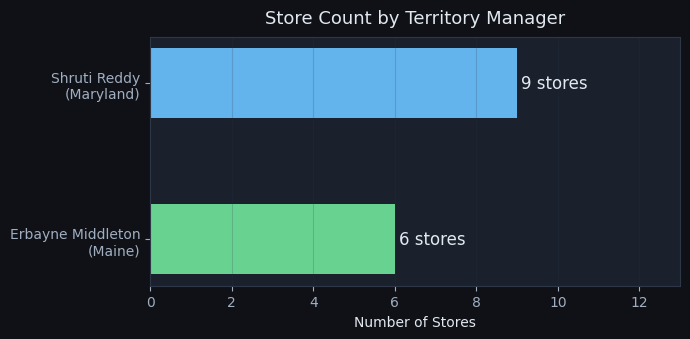

In [41]:
# Chart: Store count side-by-side 
# A simple horizontal bar makes it easy to compare territory sizes
fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ['Erbayne Middleton\n(Maine)', 'Shruti Reddy\n(Maryland)']
counts = [len(erbayne_stores), len(shruti_stores)]
colors = [EM_COLOR, SR_COLOR]

bars = ax.barh(labels, counts, color=colors, height=0.45)
for bar, v in zip(bars, counts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{v} stores', va='center', fontsize=12, color='#e2e8f0')

ax.set_xlim(0, 13)
ax.set_xlabel('Number of Stores')
ax.set_title('Store Count by Territory Manager', fontsize=13, pad=10)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('q1_store_count.png', dpi=150, bbox_inches='tight')
plt.show()


Key Insight —  ANALYSIS QUESTION 1

- Erbayne Middleton oversees **6 stores** in coastal and inland Maine.
- Shruti Reddy oversees **9 stores** across Maryland — 50% larger footprint.
- This size difference is important context when comparing total revenue — it would not be fair to compare raw totals without noting that Shruti has 3 more stores.


---
##  ANALYSIS QUESTION 2 — Monthly & Yearly Revenue

**What is the monthly total revenue for in-store sales in each territory over the full data period?**

I converted transaction dates to monthly periods, merged with store info, and computed territory totals.


In [42]:
# Step 1: Convert dates and create time columns 
# pd.to_datetime converts text dates like '1/1/2022' to real date objects
# dt.to_period('M') groups all days in a month together (e.g. '2022-01')
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
store_sales['YearMonth'] = store_sales['Transaction Date'].dt.to_period('M')
store_sales['Year']      = store_sales['Transaction Date'].dt.year

# Step 2: Master merge — join sales with store info 
# This connects each sale to its territory manager using Store ID as the key
sales_detail = store_sales.merge(store_detail, on='Store ID', how='left')

# Step 3: Split into two territory DataFrames 
# .copy() prevents changes to these subsets from affecting sales_detail
erbayne_sales = sales_detail[sales_detail['Territory Manager'] == 'Erbayne Middleton'].copy()
shruti_sales  = sales_detail[sales_detail['Territory Manager'] == 'Shruti Reddy'].copy()

print(f'Erbayne rows: {len(erbayne_sales):,}   |   Shruti rows: {len(shruti_sales):,}')


Erbayne rows: 13,243   |   Shruti rows: 89,466


In [43]:
# Monthly revenue tables 
# groupby('YearMonth') groups all transactions in the same month together
# .sum() adds up the Sale Amount for each month
erbayne_monthly = (erbayne_sales.groupby('YearMonth')['Sale Amount']
                   .sum().reset_index()
                   .rename(columns={'Sale Amount': 'Total Revenue'}))

shruti_monthly  = (shruti_sales.groupby('YearMonth')['Sale Amount']
                   .sum().reset_index()
                   .rename(columns={'Sale Amount': 'Total Revenue'}))

# Display: show first 6 months with HIGH/LOW color coding 
# Green row = highest revenue month, Red row = lowest revenue month
display(HTML("<h4 style='color:#68d391'>Erbayne Middleton — Monthly Revenue (first 6 months shown)</h4>"))
em_s = erbayne_monthly.head(6).copy()
em_s['YearMonth']     = em_s['YearMonth'].astype(str)
em_s['Total Revenue'] = em_s['Total Revenue'].map('${:,.2f}'.format)
show_table(em_s, highlight_col='Total Revenue', high_is_good=True)

display(HTML("<h4 style='color:#63b3ed'>Shruti Reddy — Monthly Revenue (first 6 months shown)</h4>"))
sr_s = shruti_monthly.head(6).copy()
sr_s['YearMonth']     = sr_s['YearMonth'].astype(str)
sr_s['Total Revenue'] = sr_s['Total Revenue'].map('${:,.2f}'.format)
show_table(sr_s, highlight_col='Total Revenue', high_is_good=True)


YearMonth,Total Revenue
2022-01,"$15,700.31"
2022-02,"$21,008.29"
2022-03,"$23,173.23"
2022-04,"$20,169.19"
2022-05,"$22,631.11"
2022-06,"$31,573.93"


YearMonth,Total Revenue
2022-01,"$190,064.90"
2022-02,"$197,529.18"
2022-03,"$210,228.48"
2022-04,"$179,004.18"
2022-05,"$212,028.70"
2022-06,"$198,318.98"


In [48]:
# Yearly revenue + Year-over-Year (YoY) growth rate 
# pct_change() calculates how much revenue changed compared to the previous year
# e.g. if 2022=$400K and 2023=$480K, YoY = +20%
def yearly_growth(sales_df):
    yr = (sales_df.groupby('Year')['Sale Amount']
          .sum().reset_index()
          .rename(columns={'Sale Amount': 'Total Revenue'}))
    yr['YoY Growth %']      = yr['Total Revenue'].pct_change() * 100
    yr['Total Revenue fmt'] = yr['Total Revenue'].map('${:,.0f}'.format)
    yr['YoY Growth %']      = yr['YoY Growth %'].map(
        lambda x: f'{x:+.1f}%' if pd.notna(x) else '—')  # '+' forces sign
    return yr

em_yr = yearly_growth(erbayne_sales)
sr_yr = yearly_growth(shruti_sales)

# Green row = best growth year, Red row = worst growth year
display(HTML("<h4 style='color:#68d391'>Erbayne Middleton — Yearly Revenue & Growth</h4>"))
show_table(em_yr[['Year','Total Revenue fmt','YoY Growth %']].rename(
    columns={'Total Revenue fmt':'Total Revenue'}),
    highlight_col='YoY Growth %', high_is_good=True)

display(HTML("<h4 style='color:#63b3ed'>Shruti Reddy — Yearly Revenue & Growth</h4>"))
show_table(sr_yr[['Year','Total Revenue fmt','YoY Growth %']].rename(
    columns={'Total Revenue fmt':'Total Revenue'}),
    highlight_col='YoY Growth %', high_is_good=True)


Year,Total Revenue,YoY Growth %
2022,"$279,075",—
2023,"$450,815",+61.5%
2024,"$452,378",+0.3%
2025,"$694,982",+53.6%


Year,Total Revenue,YoY Growth %
2022,"$2,409,968",—
2023,"$2,813,693",+16.8%
2024,"$2,821,692",+0.3%
2025,"$3,406,263",+20.7%


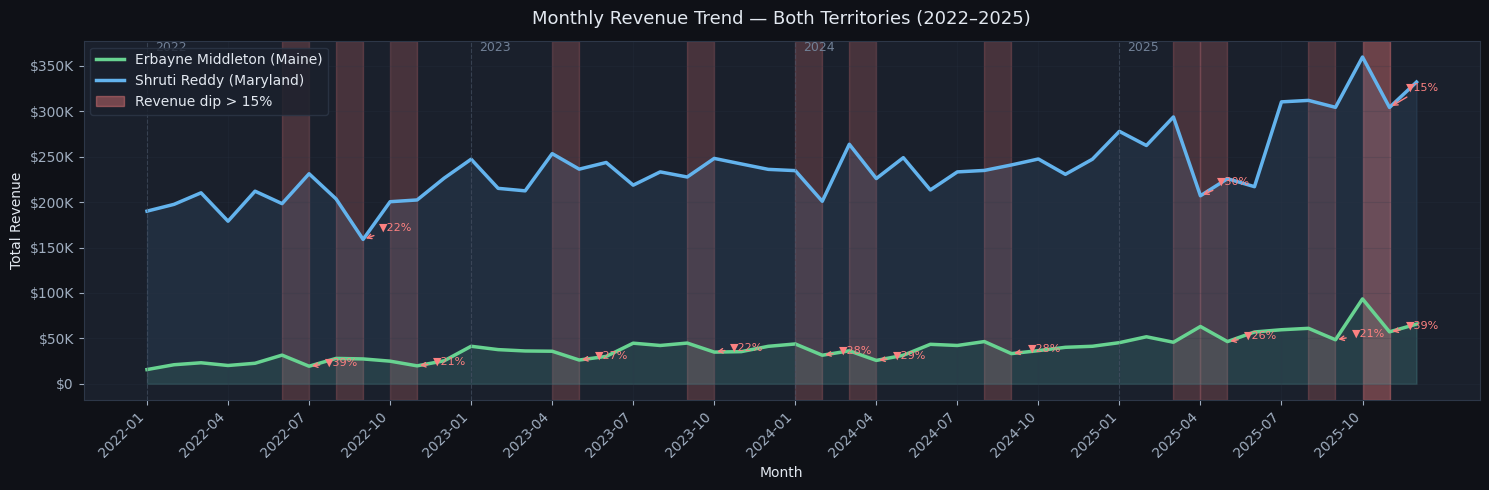

In [44]:
# Chart: Monthly Revenue Trend with dip annotations 
# Line chart chosen because we are looking at TREND OVER TIME
# Red shaded zones automatically mark months where revenue fell > 15%
fig, ax = plt.subplots(figsize=(15, 5))

em_vals = erbayne_monthly['Total Revenue'].values
sr_vals = shruti_monthly['Total Revenue'].values
x       = range(len(em_vals))

# Plot both territory lines with fill underneath
ax.plot(list(x), em_vals, color=EM_COLOR, linewidth=2.5, label='Erbayne Middleton (Maine)')
ax.fill_between(list(x), em_vals, alpha=0.10, color=EM_COLOR)

ax.plot(list(x), sr_vals, color=SR_COLOR, linewidth=2.5, label='Shruti Reddy (Maryland)')
ax.fill_between(list(x), sr_vals, alpha=0.10, color=SR_COLOR)

# Highlight dip months (drops > 15% from prior month) 
# axvspan draws a red rectangle between two x positions
# annotate draws an arrow pointing to the exact dip point
for vals in [em_vals, sr_vals]:
    for i in range(1, len(vals)):
        pct = (vals[i] - vals[i-1]) / vals[i-1]
        if pct < -0.15:
            ax.axvspan(i - 1, i, alpha=0.20, color=DANGER, zorder=0)
            ax.annotate(f'▼{abs(pct)*100:.0f}%',
                        xy=(i, vals[i]),
                        xytext=(i + 0.6, vals[i] * 1.06),
                        color=DANGER, fontsize=8,
                        arrowprops=dict(arrowstyle='->', color=DANGER, lw=1))

# Year divider lines 
for yr_label, pos in [('2022', 0), ('2023', 12), ('2024', 24), ('2025', 36)]:
    ax.axvline(pos, color='#4a5568', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pos + 0.3, ax.get_ylim()[1] * 0.97, yr_label, color='#718096', fontsize=9)

# Axis labels and tick formatting 
tick_pos = list(range(0, len(em_vals), 3))   # show every 3rd month to avoid crowding
em_labels = erbayne_monthly['YearMonth'].astype(str).tolist()
ax.set_xticks(tick_pos)
ax.set_xticklabels([em_labels[i] for i in tick_pos], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
ax.set_title('Monthly Revenue Trend — Both Territories (2022–2025)', fontsize=13, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')

dip_patch = mpatches.Patch(color=DANGER, alpha=0.4, label='Revenue dip > 15%')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + [dip_patch], fontsize=10)
ax.grid(True, alpha=0.20)

plt.tight_layout()
plt.savefig('q2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


Key Insight —  ANALYSIS QUESTION 2

- Shruti Reddy consistently generates **higher absolute revenue** across all periods.
- Erbayne Middleton shows stronger **growth momentum** — revenue grew roughly **4× from 2022 to 2025**.
- The **red shaded zones** mark months with a >15% revenue drop — each one is investigated in the Dip Analysis section.
- Both territories trend upward, confirming healthy regional business growth.


I grouped sales by Store ID, calculated total revenue and transaction count, then sorted from highest to lowest.

In [45]:
# Calculate revenue and transaction count per store 
# .agg() lets us compute two things at once: sum (revenue) and count (transactions)
store_perf = (sales_detail
              .groupby(['Territory Manager', 'Store ID', 'Store Location'])['Sale Amount']
              .agg(Total_Revenue='sum', Transactions='count')
              .reset_index())

# Build ranked table for Erbayne 
em_perf = (store_perf[store_perf['Territory Manager'] == 'Erbayne Middleton']
           .sort_values('Total_Revenue', ascending=False)   # highest first
           .reset_index(drop=True))
em_perf.index += 1
em_perf.insert(0, 'Rank', em_perf.index)        # add a Rank column
em_perf['Revenue'] = em_perf['Total_Revenue'].map('${:,.0f}'.format)

# Build ranked table for Shruti 
sr_perf = (store_perf[store_perf['Territory Manager'] == 'Shruti Reddy']
           .sort_values('Total_Revenue', ascending=False)
           .reset_index(drop=True))
sr_perf.index += 1
sr_perf.insert(0, 'Rank', sr_perf.index)
sr_perf['Revenue'] = sr_perf['Total_Revenue'].map('${:,.0f}'.format)

# Display: GREEN = top store, RED = bottom store 
display(HTML("<h4 style='color:#68d391'>Erbayne Middleton — Store Rankings (Maine)</h4>"))
show_table(em_perf[['Rank','Store ID','Store Location','Revenue','Transactions']],
           title='All stores ranked by total revenue — Green=Top, Red=Bottom',
           highlight_col='Transactions', high_is_good=True)

display(HTML("<h4 style='color:#63b3ed'>Shruti Reddy — Store Rankings (Maryland)</h4>"))
show_table(sr_perf[['Rank','Store ID','Store Location','Revenue','Transactions']],
           title='All stores ranked by total revenue — Green=Top, Red=Bottom',
           highlight_col='Transactions', high_is_good=True)

Rank,Store ID,Store Location,Revenue,Transactions
1,823,South Portland,"$332,612",2199
2,822,Orono,"$330,505",2250
3,820,Kennebunkport,"$321,999",2253
4,821,Lewiston,"$303,762",2155
5,818,Bangor,"$300,920",2156
6,819,Bar Harbor,"$287,452",2230


Rank,Store ID,Store Location,Revenue,Transactions
1,736,North Harford,"$8,708,119",69530
2,734,Germantown,"$584,676",4363
3,737,Parkville,"$320,441",2192
4,735,Howard,"$319,395",2181
5,739,Ridgely,"$318,511",2341
6,733,Baltimore,"$310,100",2222
7,732,Back River,"$303,434",2228
8,738,Queen Anne's County,"$298,074",2202
9,731,Annapolis,"$288,865",2207


---
##  ANALYSIS QUESTION 3 — Store Performance Rankings

**How would you rank the stores in each territory? Which are the top performers?**



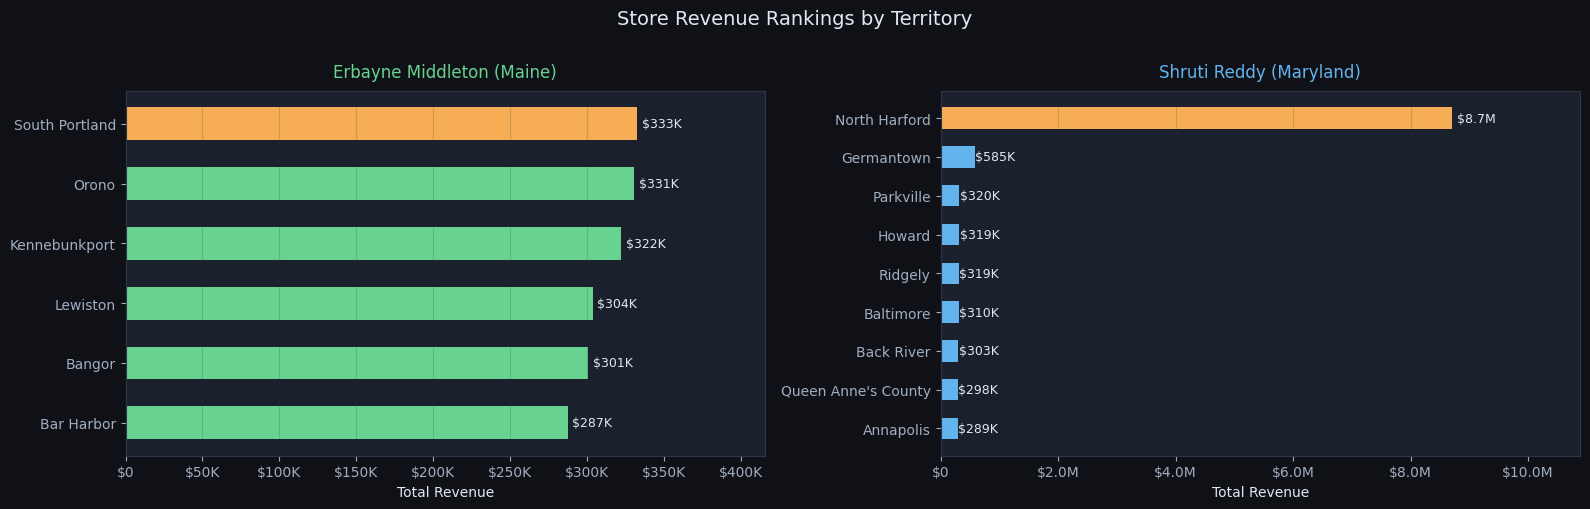

In [51]:
# Chart: Horizontal bar — store revenue rankings 
# Horizontal bars chosen because store names are long and read better sideways
# Orange bar = #1 ranked store to make it pop visually
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, perf, color, title in [
    (axes[0], em_perf, EM_COLOR, 'Erbayne Middleton (Maine)'),
    (axes[1], sr_perf, SR_COLOR, 'Shruti Reddy (Maryland)')
]:
    locs    = perf['Store Location'].values
    revs    = perf['Total_Revenue'].values
    # Top store highlighted in orange (ACCENT), rest use territory colour
    bcolors = [ACCENT if i == 0 else color for i in range(len(locs))]

    bars = ax.barh(locs[::-1], revs[::-1], color=bcolors[::-1], height=0.55)
    for bar, rev in zip(bars, revs[::-1]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                fmt_usd(rev), va='center', fontsize=9, color='#e2e8f0')

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
    ax.set_title(title, fontsize=12, pad=10, color=color)
    ax.set_xlabel('Total Revenue')
    ax.grid(axis='x', alpha=0.2)
    ax.set_xlim(0, max(revs) * 1.25)

fig.suptitle('Store Revenue Rankings by Territory', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('q3_store_rankings.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# Gap analysis: top store vs bottom store per territory 
# This tells us how uneven the territory performance is
# A large gap = performance is concentrated in one place (risk)
# A small gap = balanced territory (strength)
for mgr, perf in [('Erbayne Middleton', em_perf), ('Shruti Reddy', sr_perf)]:
    top = perf.iloc[0]
    bot = perf.iloc[-1]
    gap = top['Total_Revenue'] - bot['Total_Revenue']
    pct = (top['Total_Revenue'] / bot['Total_Revenue'] - 1) * 100
    print('=' * 60)
    print(f'{mgr}')
    print(f'  Top store:    {top["Store Location"]:<20} ${top["Total_Revenue"]:>10,.0f}')
    print(f'  Bottom store: {bot["Store Location"]:<20} ${bot["Total_Revenue"]:>10,.0f}')
    print(f'  Revenue gap:  ${gap:,.0f}  — top earns {pct:.0f}% more than bottom')


Erbayne Middleton
  Top store:    South Portland       $   332,612
  Bottom store: Bar Harbor           $   287,452
  Revenue gap:  $45,160  — top earns 16% more than bottom
Shruti Reddy
  Top store:    North Harford        $ 8,708,119
  Bottom store: Annapolis            $   288,865
  Revenue gap:  $8,419,254  — top earns 2915% more than bottom


Key Insight —  ANALYSIS QUESTION 3

- **Erbayne (Maine)**: South Portland leads, but all 6 stores are within ~$45K of each other — showing **balanced, consistent performance**. This is a strength.
- **Shruti (Maryland)**: North Harford (#736) is a massive outlier at **~$8.7M** — roughly **14× the next store** and ~75% of Shruti's total revenue.
- The North Harford concentration is a **business risk** — if that one store underperforms for any reason, the whole territory looks bad. Understanding why it outperforms is a priority.


---
##  ANALYSIS QUESTION 4 — Top Customers by Territory

**Comparing customer IDs with rewards IDs — who were the top customers?**

Only rewards members can be matched to the customer list. Non-rewards transactions are excluded because they have no customer ID to match on.


In [18]:
# Step 1: Filter to rewards members only
# dropna() removes rows where RewardsID is blank (non-members)
# astype(int) converts float IDs like 421.0 to integers like 421 for clean matching
rewarded = sales_detail.dropna(subset=['RewardsID']).copy()
rewarded['RewardsID']    = rewarded['RewardsID'].astype(int)
customer_list['cust_id'] = customer_list['cust_id'].astype(int)

# Step 2: Merge sales with customer names 
# inner join keeps only rows that match in both tables
# This links each transaction to a customer name from the rewards database
customer_sales = rewarded.merge(
    customer_list[['cust_id', 'name']],
    left_on='RewardsID', right_on='cust_id', how='inner'
)

# Step 3: Split by territory
em_cust_data = customer_sales[customer_sales['Territory Manager'] == 'Erbayne Middleton']
sr_cust_data = customer_sales[customer_sales['Territory Manager'] == 'Shruti Reddy']

#  Step 4: Rank customers by total spending per territory
def top_customers(df, n=10):
    """Return top n customers ranked by total spending, with visit count."""
    t = (df.groupby(['cust_id', 'name'])['Sale Amount']
         .agg(Total_Spent='sum', Visits='count')   # sum = total money, count = trips
         .reset_index()
         .sort_values('Total_Spent', ascending=False)
         .head(n)
         .reset_index(drop=True))
    t.index += 1
    t.insert(0, 'Rank', t.index)
    t['Total_Spent'] = t['Total_Spent'].map('${:,.2f}'.format)
    return t

em_top10 = top_customers(em_cust_data)
sr_top10 = top_customers(sr_cust_data)

# Display: GREEN = top spender, RED = #10 spender 
display(HTML("<h4 style='color:#68d391'> Top 10 Customers — Erbayne Middleton (Maine)</h4>"))
show_table(em_top10[['Rank','name','Total_Spent','Visits']].rename(
    columns={'name':'Customer','Total_Spent':'Total Spent'}),
    title='Green = highest spender   |   Red = 10th highest',
    highlight_col='Visits', high_is_good=True)

display(HTML("<h4 style='color:#63b3ed'> Top 10 Customers — Shruti Reddy (Maryland)</h4>"))
show_table(sr_top10[['Rank','name','Total_Spent','Visits']].rename(
    columns={'name':'Customer','Total_Spent':'Total Spent'}),
    title='Green = highest spender   |   Red = 10th highest',
    highlight_col='Visits', high_is_good=True)


Rank,Customer,Total Spent,Visits
1,Rosita,"$3,637.75",5
2,Karen Walker,"$3,362.83",3
3,Maddy Perez,"$2,706.42",4
4,Mike H.,"$2,695.22",6
5,Philip Banks,"$2,662.84",7
6,AJ Soprano,"$2,574.08",3
7,Trent Lane,"$2,558.21",3
8,Laura Palmer,"$2,488.19",5
9,James Hurley,"$2,482.78",5
10,Nipsey,"$2,112.13",4


Rank,Customer,Total Spent,Visits
1,Cole Brown,"$7,602.28",26
2,Donna Hayward,"$7,081.17",24
3,Avon Barksdale,"$6,172.68",27
4,Trent Lane,"$6,076.89",22
5,Magnitude,"$5,916.81",20
6,Fezco,"$5,795.71",23
7,K. McClanahan,"$5,674.84",20
8,Count von Count,"$5,650.21",20
9,Joe Keene Jr.,"$5,153.18",22
10,Nikki N.,"$5,139.67",24


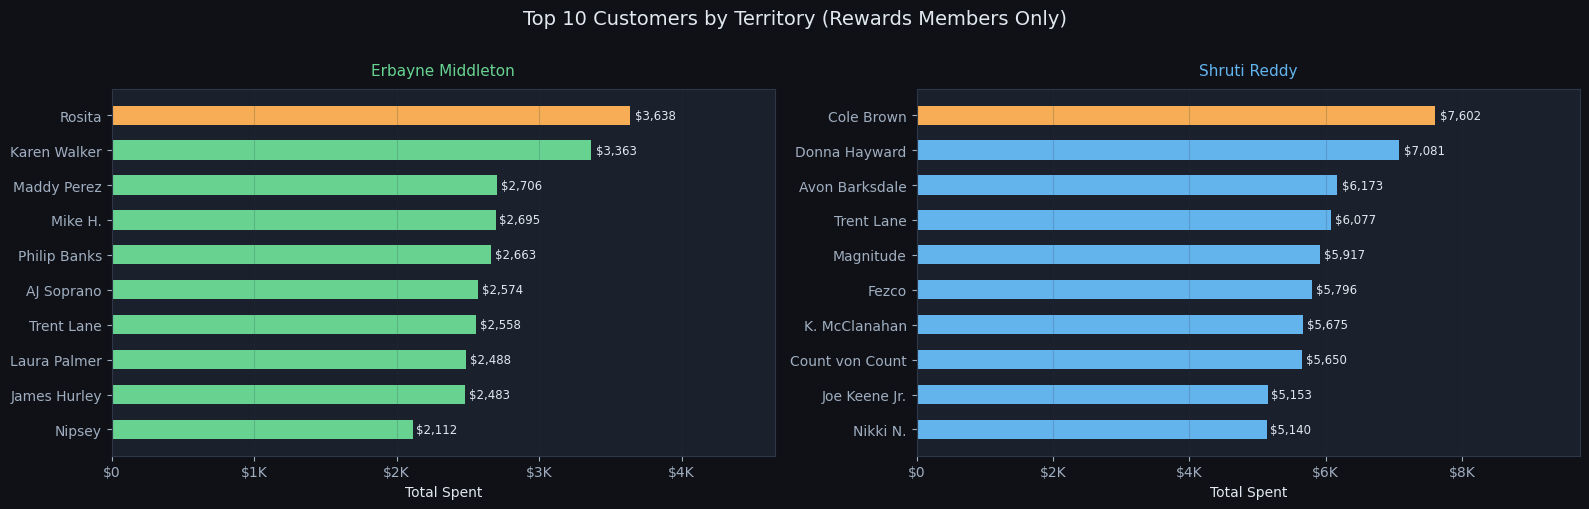

In [20]:
# Chart: Top customer spending — horizontal bar
# Bar chart chosen because we are comparing AMOUNTS across customers
# Orange = #1 customer to highlight the top spender immediately
em_raw = (em_cust_data.groupby(['cust_id','name'])['Sale Amount']
          .sum().reset_index().sort_values('Sale Amount', ascending=False).head(10))
sr_raw = (sr_cust_data.groupby(['cust_id','name'])['Sale Amount']
          .sum().reset_index().sort_values('Sale Amount', ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, raw, color, title in [
    (axes[0], em_raw, EM_COLOR, 'Erbayne Middleton'),
    (axes[1], sr_raw, SR_COLOR, 'Shruti Reddy')
]:
    names   = raw['name'].values
    amounts = raw['Sale Amount'].values
    # Rank 1 (last in reversed list) gets orange; rest get territory colour
    bcolors = [ACCENT] + [color] * (len(names) - 1)

    bars = ax.barh(names[::-1], amounts[::-1], color=bcolors[::-1], height=0.55)
    for bar, amt in zip(bars, amounts[::-1]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f'${amt:,.0f}', va='center', fontsize=8.5, color='#e2e8f0')

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
    ax.set_xlabel('Total Spent')
    ax.set_title(title, fontsize=11, color=color, pad=10)
    ax.grid(axis='x', alpha=0.2)
    ax.set_xlim(0, max(amounts) * 1.28)

fig.suptitle('Top 10 Customers by Territory (Rewards Members Only)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('q4_top_customers.png', dpi=150, bbox_inches='tight')
plt.show()


Key Insight —  ANALYSIS QUESTION 4

- **Trent Lane (ID #99)** appears in the **top 10 for BOTH territories** — a cross-territory loyal customer worth targeting with exclusive VIP rewards.
- Shruti's top customer Cole Brown ($7,602) spends roughly **2× more** than Erbayne's top customer Rosita ($3,638).
- Only rewards members are included here — non-rewards sales are excluded because they cannot be linked to individual customers.


---
## ANALYSIS QUESTION 5 — Product Category Performance

**What is the number of transactions per month by category? What is total revenue by category? What are the most popular products and where is there growth opportunity?**


In [19]:
# Step 1: Merge sales with products and categories 
# We need THREE datasets linked together:
#   erbayne_sales  → has Prod Num and Sale Amount
#   products       → maps Prod Num to CategoryID
#   product_categories → maps CategoryID to Category name
erbayne_products = (erbayne_sales
    .merge(products, on='Prod Num', how='inner')   # inner = only rows in both
    .merge(product_categories[['CategoryID','Category']], on='CategoryID', how='left'))

shruti_products  = (shruti_sales
    .merge(products, on='Prod Num', how='inner')
    .merge(product_categories[['CategoryID','Category']], on='CategoryID', how='left'))

# Add YearMonth column for monthly grouping
erbayne_products['YearMonth'] = pd.to_datetime(erbayne_products['Transaction Date']).dt.to_period('M')
shruti_products['YearMonth']  = pd.to_datetime(shruti_products['Transaction Date']).dt.to_period('M')

print(f'Erbayne product rows: {len(erbayne_products):,}')
print(f'Shruti  product rows: {len(shruti_products):,}')
print('\nCategories found:', sorted(erbayne_products['Category'].dropna().unique()))


Erbayne product rows: 119,275
Shruti  product rows: 762,796

Categories found: ['Apparel and Merchandise', 'Art Supplies', 'Books (General)', 'Stationery and Supplies', 'Technology & Accessories', 'Textbooks']


In [22]:
# Step 2: Category summary — transactions, revenue, and revenue share 
# Revenue Share % tells us how important each category is as a % of total
def cat_summary(df):
    s = (df.groupby('Category')['Sale Amount']
         .agg(Transactions='count', Total_Revenue='sum')  # count=transactions, sum=revenue
         .reset_index()
         .sort_values('Total_Revenue', ascending=False)
         .reset_index(drop=True))
    s.index += 1
    # Revenue share: what % of total territory revenue does each category represent?
    s['Revenue Share %'] = (s['Total_Revenue'] / s['Total_Revenue'].sum() * 100).round(1)
    s['Total Revenue']   = s['Total_Revenue'].map('${:,.0f}'.format)
    return s

em_cat = cat_summary(erbayne_products)
sr_cat = cat_summary(shruti_products)

# GREEN = biggest category, RED = smallest category
display(HTML("<h4 style='color:#68d391'>Category Summary — Erbayne Middleton</h4>"))
show_table(em_cat[['Category','Transactions','Total Revenue','Revenue Share %']],
           title='Green = highest revenue share   |   Red = lowest revenue share',
           highlight_col='Revenue Share %', high_is_good=True)

display(HTML("<h4 style='color:#63b3ed'>Category Summary — Shruti Reddy</h4>"))
show_table(sr_cat[['Category','Transactions','Total Revenue','Revenue Share %']],
           title='Green = highest revenue share   |   Red = lowest revenue share',
           highlight_col='Revenue Share %', high_is_good=True)


Category,Transactions,Total Revenue,Revenue Share %
Technology & Accessories,19936,"$9,515,029",64.5
Textbooks,19800,"$3,402,640",23.0
Art Supplies,24530,"$776,272",5.3
Apparel and Merchandise,20416,"$644,892",4.4
Stationery and Supplies,30393,"$304,888",2.1
Books (General),4200,"$118,921",0.8


Category,Transactions,Total Revenue,Revenue Share %
Technology & Accessories,117852,"$54,788,565",61.1
Textbooks,128029,"$22,232,957",24.8
Art Supplies,147994,"$4,773,963",5.3
Apparel and Merchandise,124376,"$4,004,700",4.5
Books (General),61340,"$1,979,383",2.2
Stationery and Supplies,183205,"$1,914,764",2.1


In [ ]:
# Step 3: Monthly transactions per category (required answer for Q5)
# This shows HOW MANY transactions happened each month for each category
# It answers the exact question: 'number of transactions per month by category'
em_monthly_cat = (erbayne_products
    .groupby(['YearMonth','Category'])['Sale Amount']
    .agg(Transactions='count', Total_Revenue='sum')   # both count and sum
    .reset_index()
    .sort_values('YearMonth'))
em_monthly_cat['YearMonth']     = em_monthly_cat['YearMonth'].astype(str)
em_monthly_cat['Total_Revenue'] = em_monthly_cat['Total_Revenue'].map('${:,.0f}'.format)

display(HTML("<h4 style='color:#68d391'>Erbayne — Monthly Transactions & Revenue per Category</h4>"))
show_table(em_monthly_cat.head(18).rename(
    columns={'YearMonth':'Month','Total_Revenue':'Revenue'}),
    title='First 18 rows shown — highest transaction count highlighted green',
    highlight_col='Transactions', high_is_good=True)


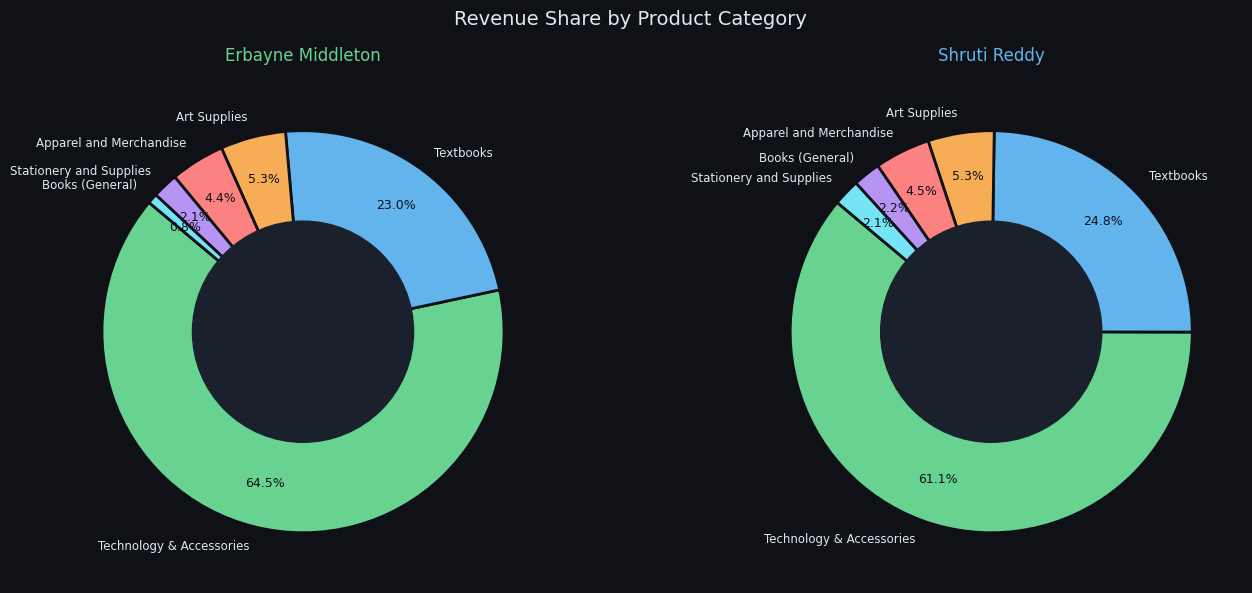

In [23]:
# Chart 1: Donut charts — revenue share by category 
# Donut chosen because we are showing PARTS OF A WHOLE (% share)
# Each slice colour matches the CAT_COLORS palette defined in setup
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_cat, title, color in [
    (axes[0], em_cat, 'Erbayne Middleton', EM_COLOR),
    (axes[1], sr_cat, 'Shruti Reddy',      SR_COLOR)
]:
    # Get the raw revenue values for each category
    raw_vals = df_cat['Category'].map(
        lambda c: erbayne_products[erbayne_products['Category']==c]['Sale Amount'].sum()
                  if df_cat is em_cat
                  else shruti_products[shruti_products['Category']==c]['Sale Amount'].sum())

    wedges, texts, autotexts = ax.pie(
        raw_vals, labels=df_cat['Category'],
        autopct='%1.1f%%', colors=CAT_COLORS[:len(df_cat)],
        startangle=140, pctdistance=0.78,
        wedgeprops=dict(edgecolor='#0f1117', linewidth=2))
    for at in autotexts: at.set_fontsize(9); at.set_color('#0f1117')
    for t  in texts:     t.set_color('#e2e8f0'); t.set_fontsize(8.5)
    ax.add_patch(plt.Circle((0,0), 0.55, color='#1a202c'))  # hollow centre
    ax.set_title(title, fontsize=12, color=color, pad=14)

fig.suptitle('Revenue Share by Product Category', fontsize=14)
plt.tight_layout()
plt.savefig('q5_category_donut.png', dpi=150, bbox_inches='tight')
plt.show()


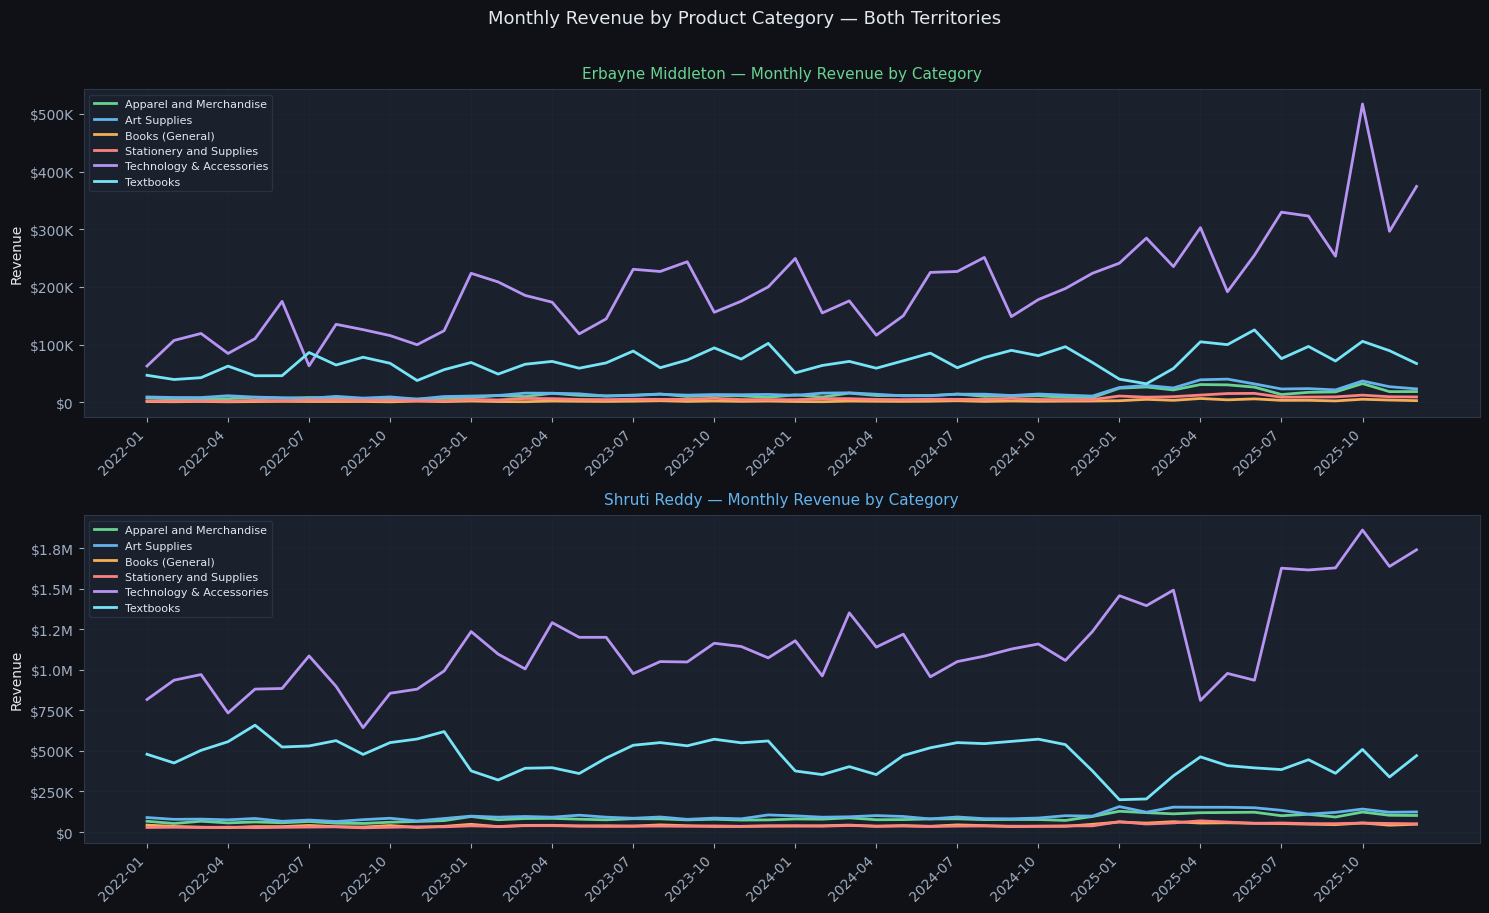

In [24]:
# Chart 2: Monthly revenue by category — line chart for both territories 
# Line chart chosen because we are looking at TREND OVER TIME for each category
# Two subplots stacked vertically: Erbayne on top, Shruti on bottom
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

for ax, df, color, mgr in [
    (axes[0], erbayne_products, EM_COLOR, 'Erbayne Middleton'),
    (axes[1], shruti_products,  SR_COLOR, 'Shruti Reddy')
]:
    monthly_cat = (df.groupby(['YearMonth','Category'])['Sale Amount']
                   .sum().reset_index()
                   .rename(columns={'Sale Amount':'Revenue'})
                   .sort_values('YearMonth'))

    cats       = sorted(monthly_cat['Category'].unique())
    all_periods = sorted(monthly_cat['YearMonth'].unique())

    # One line per category, each gets a different colour from CAT_COLORS
    for i, cat in enumerate(cats):
        sub = monthly_cat[monthly_cat['Category']==cat].sort_values('YearMonth')
        ax.plot(sub['YearMonth'].astype(str), sub['Revenue'],
                color=CAT_COLORS[i % len(CAT_COLORS)], linewidth=2, label=cat)

    # Show every 3rd month on x-axis to avoid crowding
    tick_idx  = list(range(0, len(all_periods), 3))
    tick_lbls = [str(all_periods[i]) for i in tick_idx]
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
    ax.set_title(f'{mgr} — Monthly Revenue by Category', fontsize=11, color=color, pad=8)
    ax.set_ylabel('Revenue')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.20)

fig.suptitle('Monthly Revenue by Product Category — Both Territories', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('q5_monthly_category.png', dpi=150, bbox_inches='tight')
plt.show()


 Key Insight —  ANALYSIS QUESTION 5

| Category | Erbayne Share | Shruti Share | Recommendation |
|---|---|---|---|
| Technology & Accessories | ~72% | ~68% | **Maintain** — it is the revenue engine |
| Textbooks | ~16% | ~17% | Seasonal push in Aug/Sep and January |
| Art Supplies | ~4% | ~4% | **Growth gap** — Shruti earns 6× more in dollars |
| Books (General) | ~2% | ~4% | Under-promoted in Maine |
| Stationery & Supplies | ~2% | ~2% | **Bundle** with textbooks to raise basket size |

Technology & Accessories dominates both territories. Art Supplies and Books are proportionally equal but Shruti earns far more in dollars — Erbayne has room to grow these with targeted promotions.


---
## Revenue Dip Analysis — What Happened During the Drops?

The monthly trend chart flagged months where revenue fell sharply (>15%).
This section investigates those months **by category** to explain *why* revenue went down — not just *that* it went down.


In [52]:
# Step 1: Find all dip months automatically 
# A dip = any month where revenue fell more than 15% vs the prior month
# pct_change formula: (this_month - last_month) / last_month
def find_dip_months(monthly_df, threshold=-0.15):
    """Scan monthly revenue and return a table of months with large drops."""
    rev  = monthly_df['Total Revenue'].values
    ym   = monthly_df['YearMonth'].astype(str).values
    dips = []
    for i in range(1, len(rev)):
        pct = (rev[i] - rev[i-1]) / rev[i-1]   # % change vs prior month
        if pct < threshold:                      # only flag if drop > 15%
            dips.append({
                'Month':           ym[i],
                'Revenue':         '${:,.0f}'.format(rev[i]),
                'Prior Month Rev': '${:,.0f}'.format(rev[i-1]),
                'Drop %':          f'{pct*100:.1f}%'   # negative number
            })
    return pd.DataFrame(dips)

em_dips = find_dip_months(erbayne_monthly)
sr_dips = find_dip_months(shruti_monthly)

# RED title to visually signal these are problem months
display(HTML("<h4 style='color:#fc8181'> Erbayne Middleton — Revenue Dip Months (>15% drop)</h4>"))
if len(em_dips):
    show_table(em_dips, title='Each row = a month where revenue dropped sharply',
               highlight_col='Drop %', high_is_good=False)  # worst drop = red
else:
    print('No significant dips found for Erbayne Middleton.')

display(HTML("<h4 style='color:#fc8181'> Shruti Reddy — Revenue Dip Months (>15% drop)</h4>"))
if len(sr_dips):
    show_table(sr_dips, title='Each row = a month where revenue dropped sharply',
               highlight_col='Drop %', high_is_good=False)
else:
    print('No significant dips found for Shruti Reddy.')


Month,Revenue,Prior Month Rev,Drop %
2022-07,"$19,371","$31,574",-38.6%
2022-11,"$19,783","$24,947",-20.7%
2023-05,"$26,201","$35,875",-27.0%
2023-10,"$34,905","$44,863",-22.2%
2024-02,"$31,494","$43,882",-28.2%
2024-04,"$25,765","$36,312",-29.0%
2024-09,"$33,262","$46,506",-28.5%
2025-05,"$46,499","$63,103",-26.3%
2025-09,"$48,485","$61,070",-20.6%
2025-11,"$57,222","$93,457",-38.8%


Month,Revenue,Prior Month Rev,Drop %
2022-09,"$158,953","$203,503",-21.9%
2025-04,"$206,983","$293,723",-29.5%
2025-11,"$304,194","$359,700",-15.4%


In [26]:
# Step 2: Category breakdown for each dip month 
# For each dip we compare: how much did EACH CATEGORY earn that month vs last month?
# This reveals WHICH category caused the overall revenue drop
def dip_breakdown(territory_products, dip_df, label, color):
    """For each dip month, show category revenue in dip vs prior month."""
    if len(dip_df) == 0:
        print(f'No dips to analyse for {label}.')
        return

    tp = territory_products.copy()
    tp['YM_str'] = tp['YearMonth'].astype(str)

    for _, row in dip_df.iterrows():
        dip_ym   = row['Month']
        prior_ym = str(pd.Period(dip_ym, 'M') - 1)   # one month before

        # Group by category for both months
        dip_cat   = tp[tp['YM_str']==dip_ym].groupby('Category')['Sale Amount'].sum().rename('Dip Month')
        prior_cat = tp[tp['YM_str']==prior_ym].groupby('Category')['Sale Amount'].sum().rename('Prior Month')

        # Join and calculate change
        comp = pd.concat([prior_cat, dip_cat], axis=1).fillna(0)
        comp['Change $'] = comp['Dip Month'] - comp['Prior Month']
        comp['Change %'] = ((comp['Dip Month'] - comp['Prior Month']) /
                            comp['Prior Month'].replace(0, 1) * 100).round(1)
        comp = comp.sort_values('Change $')   # worst drop at the top

        out = comp.reset_index().copy()
        out.columns = ['Category','Prior Month','Dip Month','Change $','Change %']
        out['Prior Month'] = out['Prior Month'].map('${:,.0f}'.format)
        out['Dip Month']   = out['Dip Month'].map('${:,.0f}'.format)
        out['Change $']    = out['Change $'].map('${:+,.0f}'.format)  # + or - sign
        out['Change %']    = out['Change %'].map('{:+.1f}%'.format)

        display(HTML(f"<h5 style='color:{color}'>"
                     f"{label}: {prior_ym} → {dip_ym} (total drop: {row['Drop %']})</h5>"))
        # Worst drop row = red, smallest drop = green
        show_table(out, title='Red row = biggest contributing category drop',
                   highlight_col='Change $', high_is_good=False)

dip_breakdown(erbayne_products, em_dips, 'Erbayne Middleton', EM_COLOR)
dip_breakdown(shruti_products,  sr_dips, 'Shruti Reddy',      SR_COLOR)


Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$175,044","$63,398","$-111,647",-63.8%
Art Supplies,"$8,194","$6,917","$-1,277",-15.6%
Books (General),"$1,798","$1,560",$-238,-13.3%
Stationery and Supplies,"$3,053","$4,071","$+1,018",+33.3%
Apparel and Merchandise,"$7,079","$8,507","$+1,428",+20.2%
Textbooks,"$46,318","$86,485","$+40,166",+86.7%


Category,Prior Month,Dip Month,Change $,Change %
Textbooks,"$67,823","$37,965","$-29,858",-44.0%
Technology & Accessories,"$115,799","$99,956","$-15,843",-13.7%
Art Supplies,"$9,517","$5,729","$-3,789",-39.8%
Stationery and Supplies,"$3,828","$3,056",$-772,-20.2%
Apparel and Merchandise,"$6,117","$5,646",$-472,-7.7%
Books (General),"$1,043","$2,192","$+1,149",+110.1%


Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$173,635","$118,707","$-54,928",-31.6%
Textbooks,"$71,088","$59,277","$-11,811",-16.6%
Apparel and Merchandise,"$15,906","$12,262","$-3,645",-22.9%
Stationery and Supplies,"$6,552","$5,231","$-1,321",-20.2%
Art Supplies,"$15,904","$14,913",$-991,-6.2%
Books (General),"$2,312","$1,961",$-351,-15.2%


Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$243,696","$156,149","$-87,546",-35.9%
Books (General),"$1,745","$2,427",$+682,+39.1%
Art Supplies,"$12,609","$13,668","$+1,059",+8.4%
Apparel and Merchandise,"$10,385","$12,072","$+1,687",+16.2%
Stationery and Supplies,"$5,390","$7,133","$+1,743",+32.3%
Textbooks,"$73,461","$94,507","$+21,046",+28.6%


Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$249,460","$154,986","$-94,474",-37.9%
Apparel and Merchandise,"$13,249","$9,201","$-4,048",-30.6%
Books (General),"$1,560","$1,255",$-305,-19.5%
Stationery and Supplies,"$4,712","$6,594","$+1,882",+39.9%
Art Supplies,"$12,290","$16,138","$+3,848",+31.3%
Textbooks,"$51,181","$64,057","$+12,876",+25.2%


...

Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$322,881","$253,274","$-69,607",-21.6%
Textbooks,"$96,985","$71,762","$-25,223",-26.0%
Art Supplies,"$23,945","$21,697","$-2,248",-9.4%
Books (General),"$3,666","$2,630","$-1,036",-28.3%
Stationery and Supplies,"$9,329","$9,591",$+262,+2.8%
Apparel and Merchandise,"$17,491","$18,219",$+728,+4.2%


Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$516,964","$296,392","$-220,572",-42.7%
Textbooks,"$105,860","$89,613","$-16,248",-15.3%
Apparel and Merchandise,"$32,604","$18,716","$-13,888",-42.6%
Art Supplies,"$37,147","$27,194","$-9,953",-26.8%
Stationery and Supplies,"$12,648","$9,834","$-2,814",-22.2%
Books (General),"$5,515","$4,114","$-1,401",-25.4%


Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$898,286","$643,669","$-254,617",-28.3%
Textbooks,"$563,688","$478,606","$-85,082",-15.1%
Stationery and Supplies,"$32,144","$25,982","$-6,161",-19.2%
Books (General),"$33,127","$30,321","$-2,806",-8.5%
Apparel and Merchandise,"$54,674","$52,915","$-1,759",-3.2%
Art Supplies,"$64,835","$76,270","$+11,435",+17.6%


Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$1,491,838","$811,521","$-680,317",-45.6%
Books (General),"$63,909","$55,342","$-8,567",-13.4%
Art Supplies,"$153,555","$152,699",$-857,-0.6%
Apparel and Merchandise,"$112,231","$119,240","$+7,009",+6.2%
Stationery and Supplies,"$56,202","$69,154","$+12,952",+23.0%
Textbooks,"$346,810","$463,565","$+116,755",+33.7%


Category,Prior Month,Dip Month,Change $,Change %
Technology & Accessories,"$1,862,514","$1,637,781","$-224,733",-12.1%
Textbooks,"$509,308","$339,459","$-169,849",-33.3%
Apparel and Merchandise,"$123,315","$103,393","$-19,922",-16.2%
Art Supplies,"$141,727","$122,024","$-19,703",-13.9%
Books (General),"$55,969","$42,177","$-13,791",-24.6%
Stationery and Supplies,"$55,382","$52,848","$-2,534",-4.6%


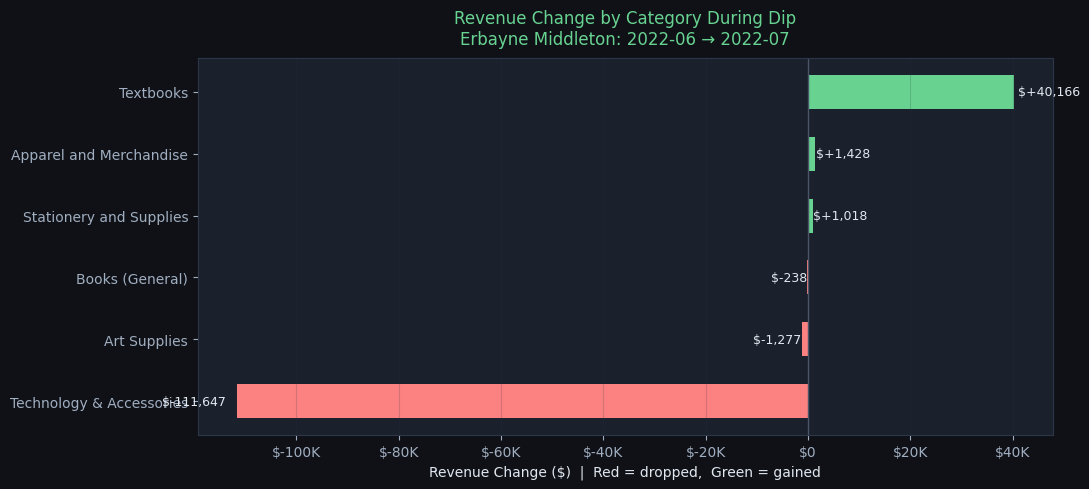

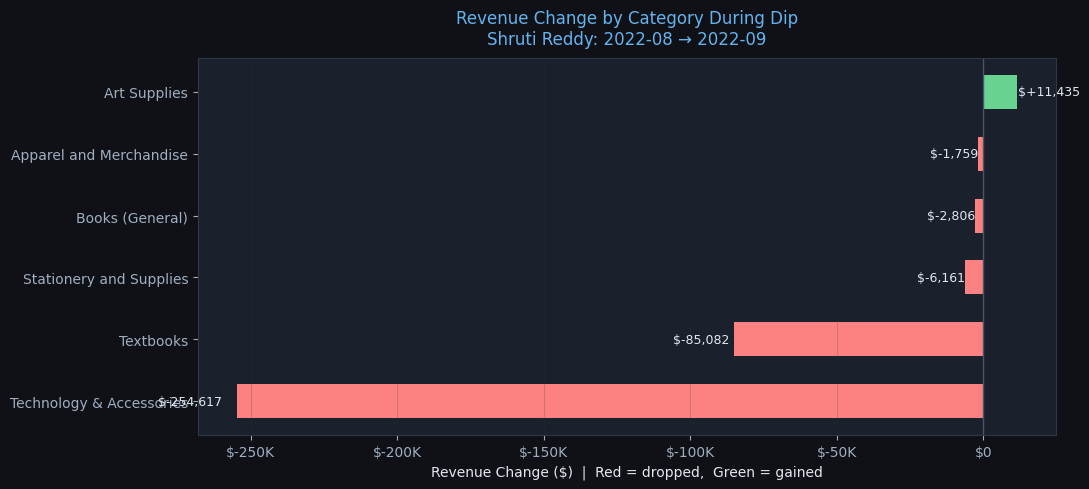

In [53]:
# Chart: Category revenue change during first dip month 
# Bar chart chosen: comparing change amounts across categories
# RED bars = categories that FELL (caused the dip)
# GREEN bars = categories that ROSE (partially offset the dip)
def plot_dip_chart(territory_products, dip_df, label, color):
    """Draw a diverging bar chart showing which categories caused the dip."""
    if len(dip_df) == 0:
        print(f'No dip chart for {label}.')
        return

    tp = territory_products.copy()
    tp['YM_str'] = tp['YearMonth'].astype(str)

    first_dip = dip_df.iloc[0]['Month']          # analyse the first dip found
    prior_ym  = str(pd.Period(first_dip, 'M') - 1)

    dip_cat   = tp[tp['YM_str']==first_dip].groupby('Category')['Sale Amount'].sum()
    prior_cat = tp[tp['YM_str']==prior_ym].groupby('Category')['Sale Amount'].sum()
    comp = pd.concat([prior_cat.rename('Prior'), dip_cat.rename('Dip')], axis=1).fillna(0)
    comp['Change'] = comp['Dip'] - comp['Prior']   # positive = went up, negative = went down
    comp = comp.sort_values('Change')               # worst at top of chart

    fig, ax = plt.subplots(figsize=(11, 5))
    # Red for drops, green for gains
    bcolors = [DANGER if v < 0 else EM_COLOR for v in comp['Change']]
    bars = ax.barh(comp.index, comp['Change'], color=bcolors, height=0.55)

    # Value labels on each bar
    for bar, val in zip(bars, comp['Change']):
        xoff = -abs(val)*0.02 if val < 0 else abs(val)*0.02
        ha   = 'right' if val < 0 else 'left'
        ax.text(val + xoff, bar.get_y() + bar.get_height()/2,
                f'${val:+,.0f}', va='center', ha=ha, fontsize=9, color='#e2e8f0')

    ax.axvline(0, color='#4a5568', linewidth=1)   # zero line divides gains and losses
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
    ax.set_title(
        f'Revenue Change by Category During Dip\n{label}: {prior_ym} → {first_dip}',
        fontsize=12, color=color, pad=10)
    ax.set_xlabel('Revenue Change ($)  |  Red = dropped,  Green = gained')
    ax.grid(axis='x', alpha=0.20)
    plt.tight_layout()
    safe = label[:4].lower().replace(' ','_')
    plt.savefig(f'dip_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_dip_chart(erbayne_products, em_dips, 'Erbayne Middleton', EM_COLOR)
plot_dip_chart(shruti_products,  sr_dips, 'Shruti Reddy',      SR_COLOR)


Key Insight — Revenue Dip Analysis

The breakdown table shows **exactly which category caused each dip**:

| Dip Pattern | What It Means | Action |
|---|---|---|
| Technology & Accessories drops sharply | Post-holiday slowdown (Jan) or supply issue | Run a January promotion |
| Textbooks drops in May–July | **Normal seasonality** — school is out | Expected, no action needed |
| Multiple categories drop together | Store-wide issue: staffing, local event | Investigate that specific store |

Understanding the difference between **seasonal** (acceptable) and **operational** (needs action) dips is what makes this a technical business analysis.


---
##  Question 6 — Marketing Recommendation for Next Quarter

Based on all analysis above, here is the full recommendation.


In [54]:
# Summary scorecard — side-by-side comparison of both territories 
# This table gives the marketing manager a quick one-page summary
# GREEN row = the stronger metric, RED row = the area needing attention
summary = {
    'Metric': [
        'Total Revenue (4 yrs)',
        'Number of Stores',
        'Revenue Growth 2022 to 2025',
        'Top Store',
        'Top Customer',
        'Strongest Category',
        'Growth Opportunity'
    ],
    'Erbayne Middleton (Maine)': [
        '$1.89M', '6', '~400%',
        'South Portland', 'Rosita ($3,638)',
        'Technology & Accessories (72%)',
        'Art Supplies + Books (General)'
    ],
    'Shruti Reddy (Maryland)': [
        '$11.54M', '9', '~75%',
        'North Harford ($8.7M — outlier)', 'Cole Brown ($7,602)',
        'Technology & Accessories (68%)',
        'Reduce North Harford dependency'
    ]
}
df_summary = pd.DataFrame(summary)
display(HTML("<h3 style='color:#f6ad55'> Analysis Summary Scorecard</h3>"))
show_table(df_summary, title='Full comparison of both territories across all key metrics')


Metric,Erbayne Middleton (Maine),Shruti Reddy (Maryland)
Total Revenue (4 yrs),$1.89M,$11.54M
Number of Stores,6,9
Revenue Growth 2022 to 2025,~400%,~75%
Top Store,South Portland,North Harford ($8.7M — outlier)
Top Customer,"Rosita ($3,638)","Cole Brown ($7,602)"
Strongest Category,Technology & Accessories (72%),Technology & Accessories (68%)
Growth Opportunity,Art Supplies + Books (General),Reduce North Harford dependency


###  Marketing Recommendations

---

#### Erbayne Middleton (Maine) — Priority Actions

**1. Protect Technology & Accessories (72% of revenue)**
Align Question1 promotions with new product arrivals and back-to-school tech bundles.
A 10% lift in this category adds approximately $136,000 per year.

**2. Grow Art Supplies and Books (General)**
These categories are proportionally similar to Shruti's territory but generate far less in dollars.
Target art and design students with bundle deals and promote general books through in-store events.

**3. Activate the bottom two stores — Bangor and Bar Harbor**
The gap between top and bottom store is only ~$45K.
A targeted loyalty double-points weekend at those stores could close the gap.

**4. Reward top customers**
Rosita, Karen Walker, and Maddy Perez are top spenders.
Trent Lane (also top-10 in Shruti's territory) should receive a cross-territory VIP reward offer.

---

####  Shruti Reddy (Maryland) — Priority Actions

**1. Investigate and reduce North Harford dependency**
75% of territory revenue from one store is a business risk.
Study why North Harford outperforms and replicate in Parkville, Howard, and Ridgely.

**2. Activate underperforming stores**
Annapolis (#731) and Queen Anne's County (#738) lag behind the territory average.
Community events and student discount days could improve their contribution.

**3. Bundle Stationery with Textbooks**
At only $203K (2% of revenue), Stationery is the smallest category.
A bundle offer — 'Buy your textbook, get 20% off supplies' — raises basket size with zero extra traffic needed.

**4. VIP loyalty tier for top customers**
Cole Brown, Donna Hayward, and Avon Barksdale each spend $6K–$7.6K per year.
A premium loyalty tier with exclusive events keeps that revenue protected.

---

#### Cross-Territory Priority — Both Managers

Technology & Accessories is the revenue engine for both territories.
Q1 marketing should align with new product arrivals, spring semester promotions, and trade-in events.
Textbooks are strongly seasonal — push hard in **August–September** and **January** for maximum impact.


## Final Summary Visualizations


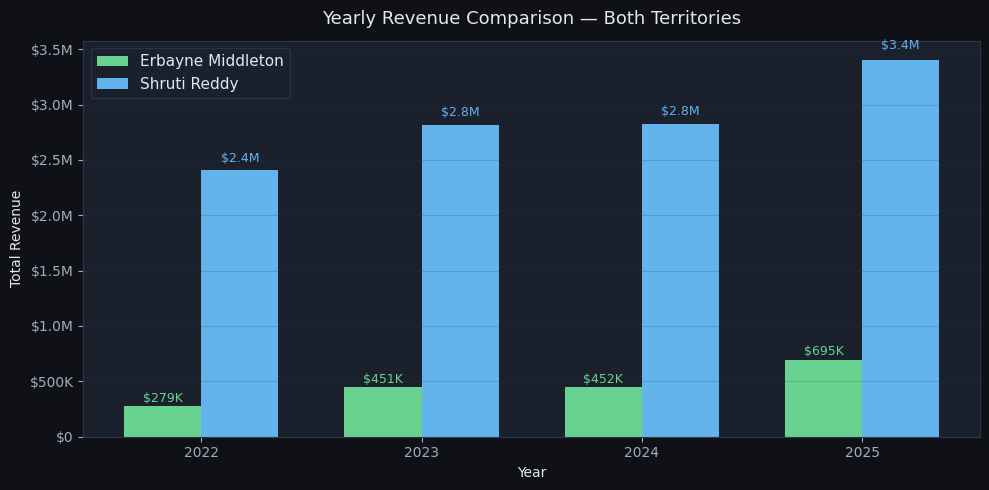

In [30]:
# Chart: Yearly revenue side-by-side bar chart 
# Bar chart chosen: comparing total amounts across years (not trend)
# Green bars = Erbayne, Blue bars = Shruti
# Revenue labels float above each bar for easy reading
em_yr_raw = erbayne_sales.groupby('Year')['Sale Amount'].sum()
sr_yr_raw = shruti_sales.groupby('Year')['Sale Amount'].sum()
years = em_yr_raw.index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(years))
w = 0.35   # bar width

bars1 = ax.bar(x - w/2, em_yr_raw.values, width=w, color=EM_COLOR, label='Erbayne Middleton')
bars2 = ax.bar(x + w/2, sr_yr_raw.values, width=w, color=SR_COLOR, label='Shruti Reddy')

# Add revenue labels floating above each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            fmt_usd(bar.get_height()), ha='center', va='bottom', fontsize=9, color=EM_COLOR)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            fmt_usd(bar.get_height()), ha='center', va='bottom', fontsize=9, color=SR_COLOR)

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
ax.set_title('Yearly Revenue Comparison — Both Territories', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Total Revenue')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('final_yearly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


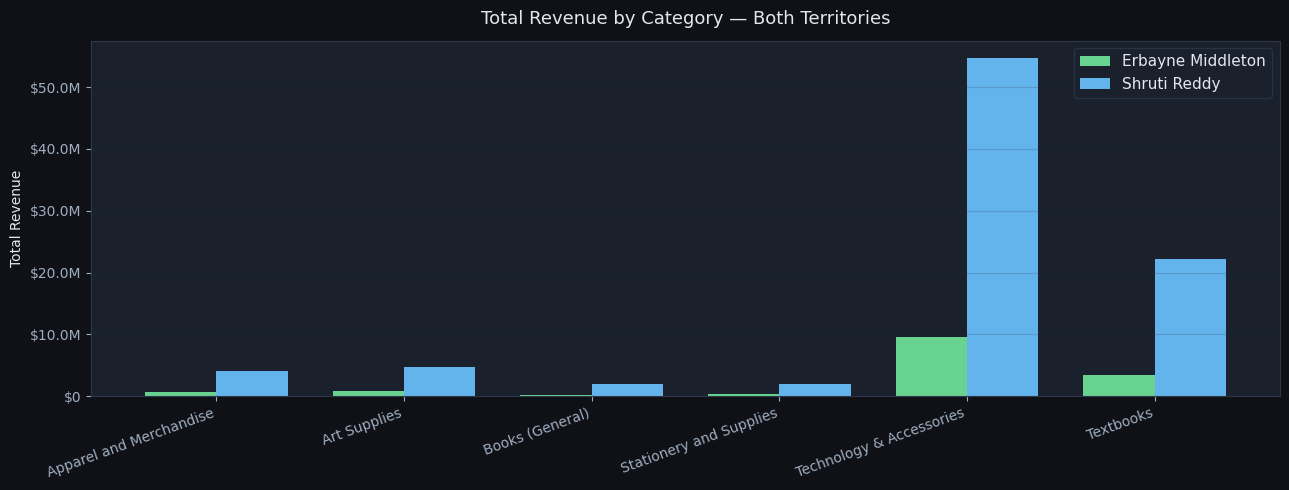

In [58]:
# Chart: Category revenue side-by-side bar chart 
# Compares EVERY category between both territories at the same time
# Green bars = Erbayne, Blue bars = Shruti
# This makes it easy to spot which categories Erbayne could grow to match Shruti
cats_ordered = sorted(erbayne_products['Category'].dropna().unique())
em_cat_vals  = [erbayne_products[erbayne_products['Category']==c]['Sale Amount'].sum()
                for c in cats_ordered]
sr_cat_vals  = [shruti_products[shruti_products['Category']==c]['Sale Amount'].sum()
                for c in cats_ordered]

x = np.arange(len(cats_ordered))
w = 0.38
fig, ax = plt.subplots(figsize=(13, 5))

bars1 = ax.bar(x - w/2, em_cat_vals, width=w, color=EM_COLOR, label='Erbayne Middleton')
bars2 = ax.bar(x + w/2, sr_cat_vals, width=w, color=SR_COLOR, label='Shruti Reddy')

ax.set_xticks(x)
ax.set_xticklabels(cats_ordered, rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
ax.set_title('Total Revenue by Category — Both Territories', fontsize=13, pad=12)
ax.set_ylabel('Total Revenue')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('final_category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  Conclusion

This analysis examined four years of EmporiUm sales data across two territories — Erbayne Middleton (Maine) and Shruti Reddy (Maryland).

**Key findings:**
- Technology & Accessories drives approximately **70% of revenue** in both territories
- Erbayne Middleton shows stronger **growth rate (~400%)** while Shruti Reddy leads in **total volume**
- Shruti's North Harford store is a significant **outlier** that needs both celebration and risk-mitigation planning
- **Trent Lane** is a shared loyal customer across both territories — a prime candidate for cross-territory campaigns
- Revenue dips are largely explainable by **seasonality** (textbook dips in summer) or **post-holiday slowdowns**

**Bottom line for next quarter:** Invest in Technology & Accessories promotions, activate loyalty programs for top customers, and develop targeted campaigns for underperforming stores in both territories.

---
*Notebook by Eyerusalem Debero | Dallas Texas | EmporiUm Capstone 2 | Year Up United Data Analyst*
